# Relation between Crime Rates and Income for New Jersey Towns
As a group we decided that an interesting urban problem to cover, was the potential relationship between the crime rate of an area, and it's average income. Many news sources lead us to believe that one of the biggest factors causing high crime rate, is the economic inequality in certain area. As a group we thought it would be interesting to try to disprove this idea, suggesting that income has no effect on crime, and there is some other possible factor causing it.


We were able to successfully test this theory, and come to our final conclusion is four easy steps.

* Collecting and Cleaning our Data
* Testing our Original Hypothesis
* Building a Machine Learning Model to Test our Hypothesis
* Our Final Discovery and Analysis

In the following sections, we will go through each step in detail, providing comments and explanations to help guide the reader through our processes and finding.

# Collecting Data
One of, if not the most important step to any good machine learning is the data collection, in order to create a good model, you first need good data. For our data collection, we wanted to find a good balance between having the size of our data, and how well we would be able to manage it and find useful evidence. Because of this, we decided to focus solely on New Jersey instead of the entire country, it also helps that everyone in the group as well as most of the class lives in New Jersey so the data would be more meaningful to a resident of the state.

We were able to get a very indepth crime report for New Jersey form an FBI report in 2019 which broken down each city in the state and gave us statistics for 10 different crimes. This was exciting to find because we were initally thinking of doing a total crime count, but by having it broken down it provides us with more features to build a better model. We can also do reports of our model now and identify which category has the highest correlation and look at it like that instead of as a total number.

For income, it was a little bit harder to find a good data set. Most sets we're looking at income average for the whole state, or average for each county while we needed income for each town. The best source we were able to find unfortunatly came from Wikipedia, but it had everything we would need to complete a full research so we decided to use it anyway.

Now that we've found and imported all the data we're going to need for our model, it's time to start cleaning it.

# Cleaning Data
Cleaning your data is the next most important step after finding the data you'll be using. To do this, first we do after importing our data is remove any new lines or blankspaces in the columns. This is important as not doing this will lead to issues later when trying to reference columns. Next we created a normalize function that lowercases the name all towns in our data, and apply that to both our crime and population data. The reason for this is because we want to merge the two datasets using the town names, and Python is case sensative meaning newark and Newark would result in two different columns. Applying a normalizer makes it so that they are merged together as one. We applied an inner merge, because we only want to keep the data if the name appears in both crime and income, this way we are able to avoid any possible NaN values.

We then renamed some columns for better readability, as well as dropped any of the columns we won't be focusing on for our analysis. We then applied a cleaner to the Income column as many of those values had symbols such as $, + and -, after cleaning them we converted them into integer values.

The last thing we did, was apply a similar cleaner to all of our crime columns. Many of the columns had numbers with commas in them which would be difficult for our system to differentiate, so we removed the commas and then converted them in integers just as did to the income.

The final results is a cleaned and merged dataset called data, where each row is a unique municipality, and our columns represent each type of crime, the population of that town and the average income of the town as well. Now that our data is ready, we can finally start working on the model and our predictions.

In [ ]:
import pandas as pd

df_crime = pd.read_csv("data/crimestats.csv")
df_income = pd.read_csv("data/popstats.csv")

df_crime.columns = df_crime.columns.str.replace("\n", " ", regex=False)
df_income.columns = df_income.columns.str.replace("\n", " ", regex=False)

def normalize(name):
    return (
        name.lower()
            .replace(" township", "")
            .replace(" city", "")
            .replace(" borough", "")
            .replace(" town", "")
            .replace(" village", "")
            .strip()
    )

df_crime["City_clean"] = df_crime["City"].apply(normalize)
df_income["Municipality_clean"] = df_income["Municipality"].apply(normalize)

data = df_crime.merge(
    df_income,
    left_on="City_clean",
    right_on="Municipality_clean",
    how="inner"
)

data = data.rename(columns={"Population_x": "Population"})
data = data.rename(columns={"Rape1": "Rape"})

data = data.drop(columns=[
    "City_clean",
    "Municipality_clean",
    "Rank",
    "Households",
    "Municipality",
    "County",
    "Population_y",
    "Per capita income"
])

# Convert 'Median household income' to numeric
data["Median household income"] = (
    data["Median household income"]
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
    .str.replace('–', '', regex=False)
)
data["Median household income"] = pd.to_numeric(data["Median household income"], errors='coerce')


# Convert crime columns and 'Population' to numeric
crime_cols_to_convert = [
    "Population",
    "Violent crime",
    "Murder and nonnegligent manslaughter",
    "Rape",
    "Robbery",
    "Aggravated assault",
    "Property crime",
    "Burglary",
    "Larceny- theft",
    "Motor vehicle theft",
    "Arson"
]

for col in crime_cols_to_convert:
    data[col] = data[col].astype(str).str.replace(',', '', regex=False) # Remove commas if any
    data[col] = pd.to_numeric(data[col], errors='coerce')


data

,City,Population,Violent crime,Murder and nonnegligent manslaughter,Rape,Robbery,Aggravated assault,Property crime,Burglary,Larceny- theft,Motor vehicle theft,Arson,Median household income
0,Aberdeen Township,18700,15,0.0,3.0,5.0,7.0,164,7.0,145,12,0.0,118085.0
1,Absecon,8436,8,0.0,1.0,2.0,5.0,236,24.0,207,5,0.0,73141.0
2,Allendale,6795,0,0.0,0.0,0.0,0.0,38,8.0,26,4,0.0,163875.0
3,Allenhurst,484,0,0.0,0.0,0.0,0.0,11,1.0,9,1,0.0,95625.0
4,Allentown,1784,0,0.0,0.0,0.0,0.0,8,2.0,6,0,0.0,113438.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,Woodlynne,2901,12,0.0,0.0,3.0,9.0,55,5.0,45,5,0.0,68125.0
490,Wood-Ridge,9328,1,0.0,0.0,0.0,1.0,45,1.0,43,1,0.0,132901.0
491,Woodstown,3440,1,0.0,0.0,0.0,1.0,34,10.0,23,1,0.0,86528.0
492,Woolwich Township,13075,2,0.0,1.0,1.0,0.0,54,5.0,45,4,1.0,152695.0


#Feature Distribution
Before actually building our model, an important step is to understand how each feature in our data behaves on it's own. To vizualize the distribution of each feature, we utitlize historgrams, which can help us easily determine if a feature is normally distributed, has any skew, or may contain and extreme outliers.

To make our data smoother, we created a new measurement called data_rates which calculates the rate of a specific crime per 1000 people. This makes sense because we have to normalize our data somehow, otherwise very large cities would overpower smaller cities by their sheer number, even if they maybe have a smalled per capita rate.

* Example
* Large City: Pop = 100,000,  Crime = 2,000, data_rate = 2
* Small City: Pop = 10,000, Crime = 400, data_rate = 4

Even though the larger city has more crime, it is technically less dangerous. Without using data_rate we could accidentally introduce an outlier, by using data_rate we reduce the change of that happening.

Once everything is calculated, we can plot the data into histograms and identify patterns that could have negative affects on our models.

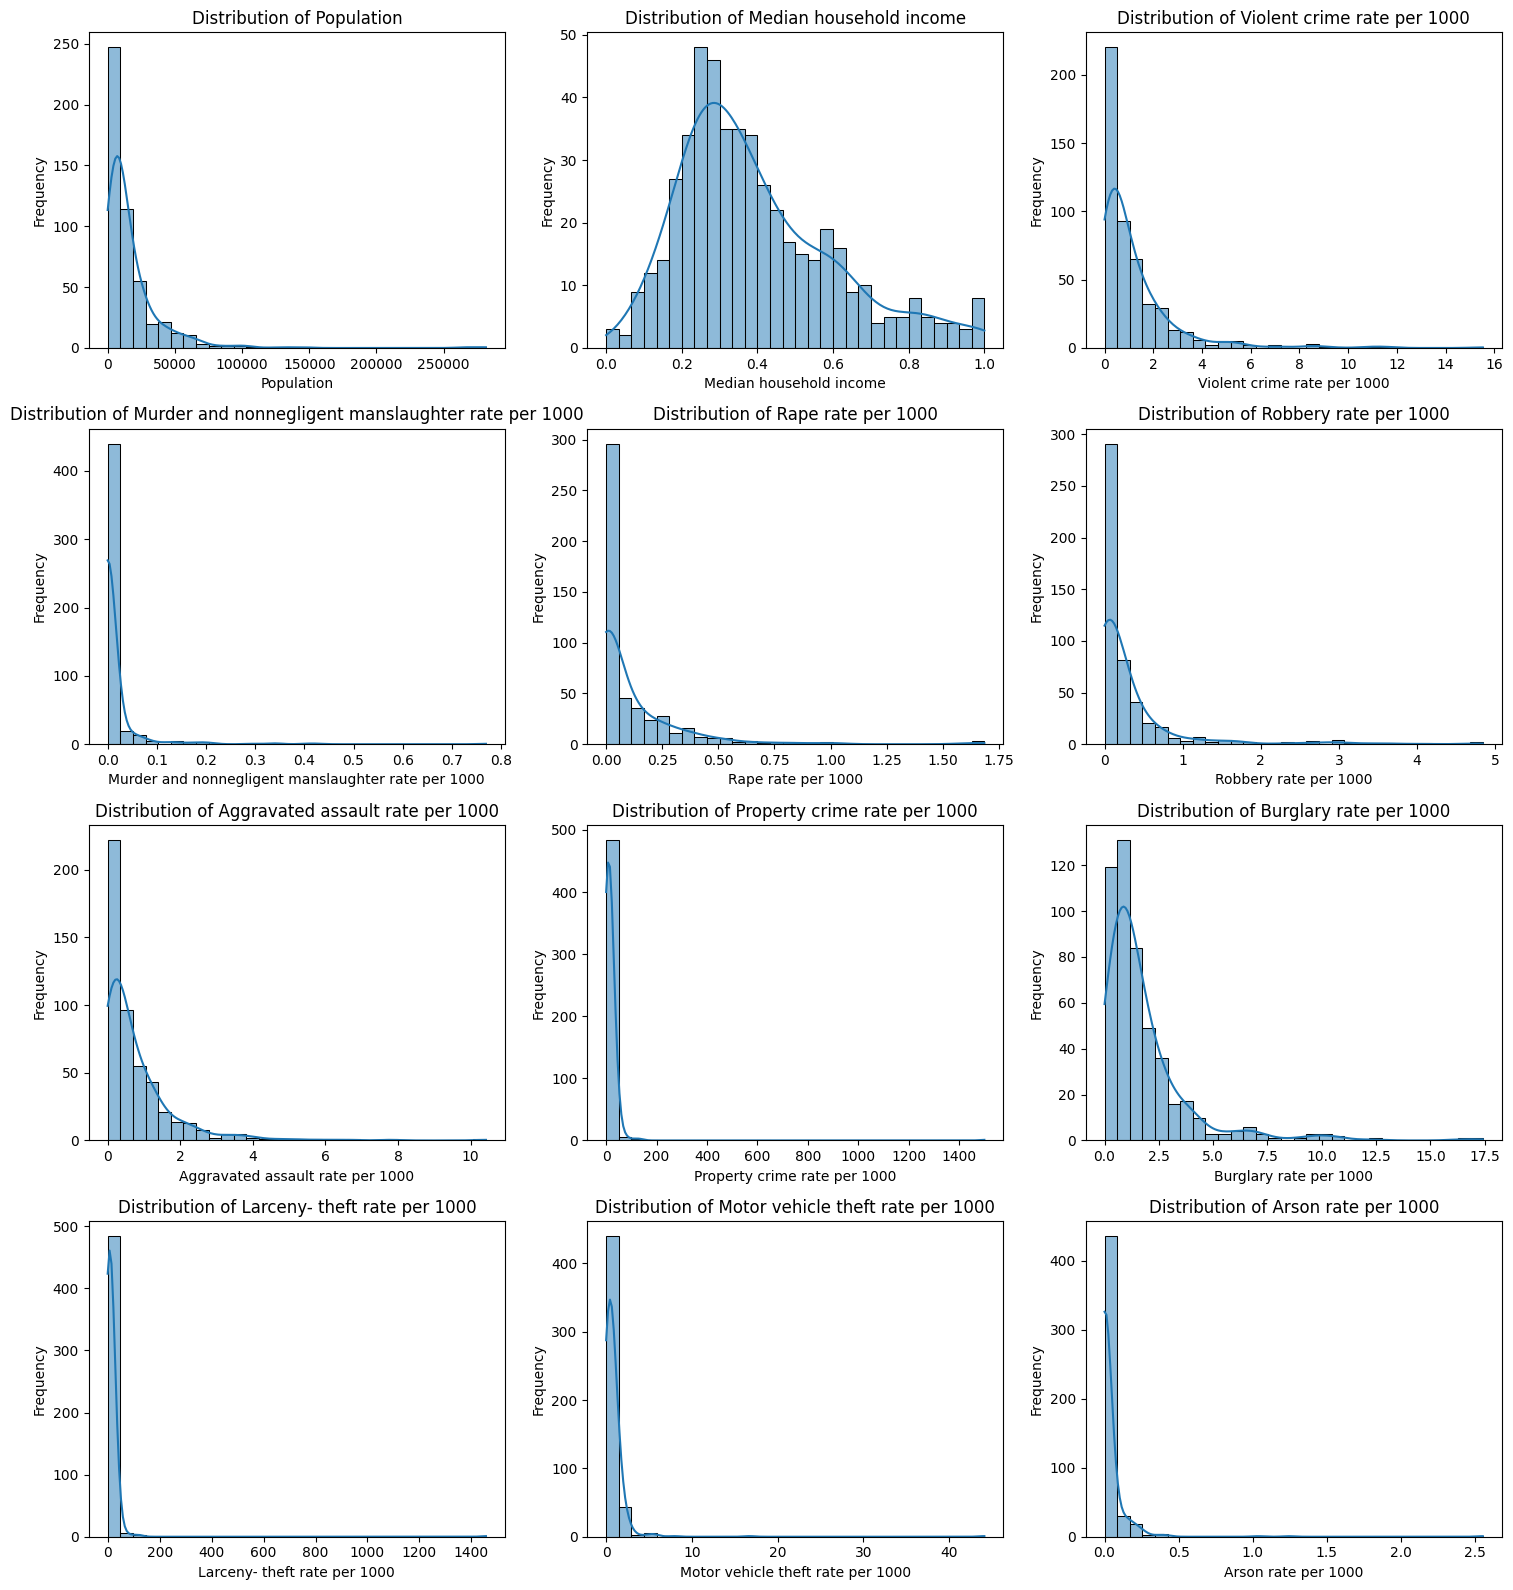

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data_rates is available and contains all rate columns
# Re-create data_rates with rates if it's not already in scope (e.g., if cells were run out of order)
if 'data_rates' not in locals() or 'data_rates' not in globals() or not all(f'{col} rate per 1000' in data_rates.columns for col in crime_cols):
    data_rates = data.copy()
    crime_cols = [
        'Violent crime',
        'Murder and nonnegligent manslaughter',
        'Rape',
        'Robbery',
        'Aggravated assault',
        'Property crime',
        'Burglary',
        'Larceny- theft',
        'Motor vehicle theft',
        'Arson'
    ]
    for col in crime_cols:
        data_rates[f'{col} rate per 1000'] = data_rates.apply(lambda row: (row[col] / row['Population']) * 1000 if row['Population'] > 0 else 0, axis=1)

# Select all rate columns, plus Population and Median household income for distribution plots
rate_cols_for_dist = ['Population', 'Median household income'] + [f'{col} rate per 1000' for col in crime_cols]

# Determine the number of rows and columns for subplots
num_plots = len(rate_cols_for_dist)
num_cols = 3 # Aim for 3 columns to keep it manageable
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(rate_cols_for_dist):
    sns.histplot(data_rates[col].dropna(), kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Histogram Summary
These graphs actually provide us with a lot of information currently and there are some instant patterns that can be recognized.

* Overall Crime Features
  - Almost all of our crime related features are heavily right-skewed
  - Most towns have very few crimes commited, while there is a small group that has very high crime rates

* Population
  - Our population is also heavily righ-skewed, with most towns being very small and only a few large cities
  - This is standard and expected in most states, but this helps justify why we used data_rates to convert crime to 1000 person rates

* Income
  - Our income has the most normal distribution with a slight skew to the right
  - Again this makes sense as this would be typical in most states, the majority of people fall within the "middle class" which would be within 1 SD unit of our median income

* Extreme Violent Crime
  - Some of the more extreme crimes such has murder, arson, aggravated assault and rape are extremely right skewed
  - Most values are clustered near 0 meaning these are low frequency events as far as our data suggests

# Correlation Heatmap Matrix
Where our histograms measured the individual distributions of each feature, we can similarly use a heatmap to measure the realtionship between two features.

Heatmaps are extremely useful as they range relationships on a scale between -1 to 1, with -1 being a strong negative relation (no correlation) and 1 being strong positive relation (strong correlation). The nice thing about heatmaps as well, is that they are color coded with -1 being blue and +1 being red making it very easy to visualize which features have the highest correlation.

We run this across all features, again implementing data_rates as to not allow large cities to overweight smaller towns, and are left with a graph that can show us which features have the strongest correlation with each other.

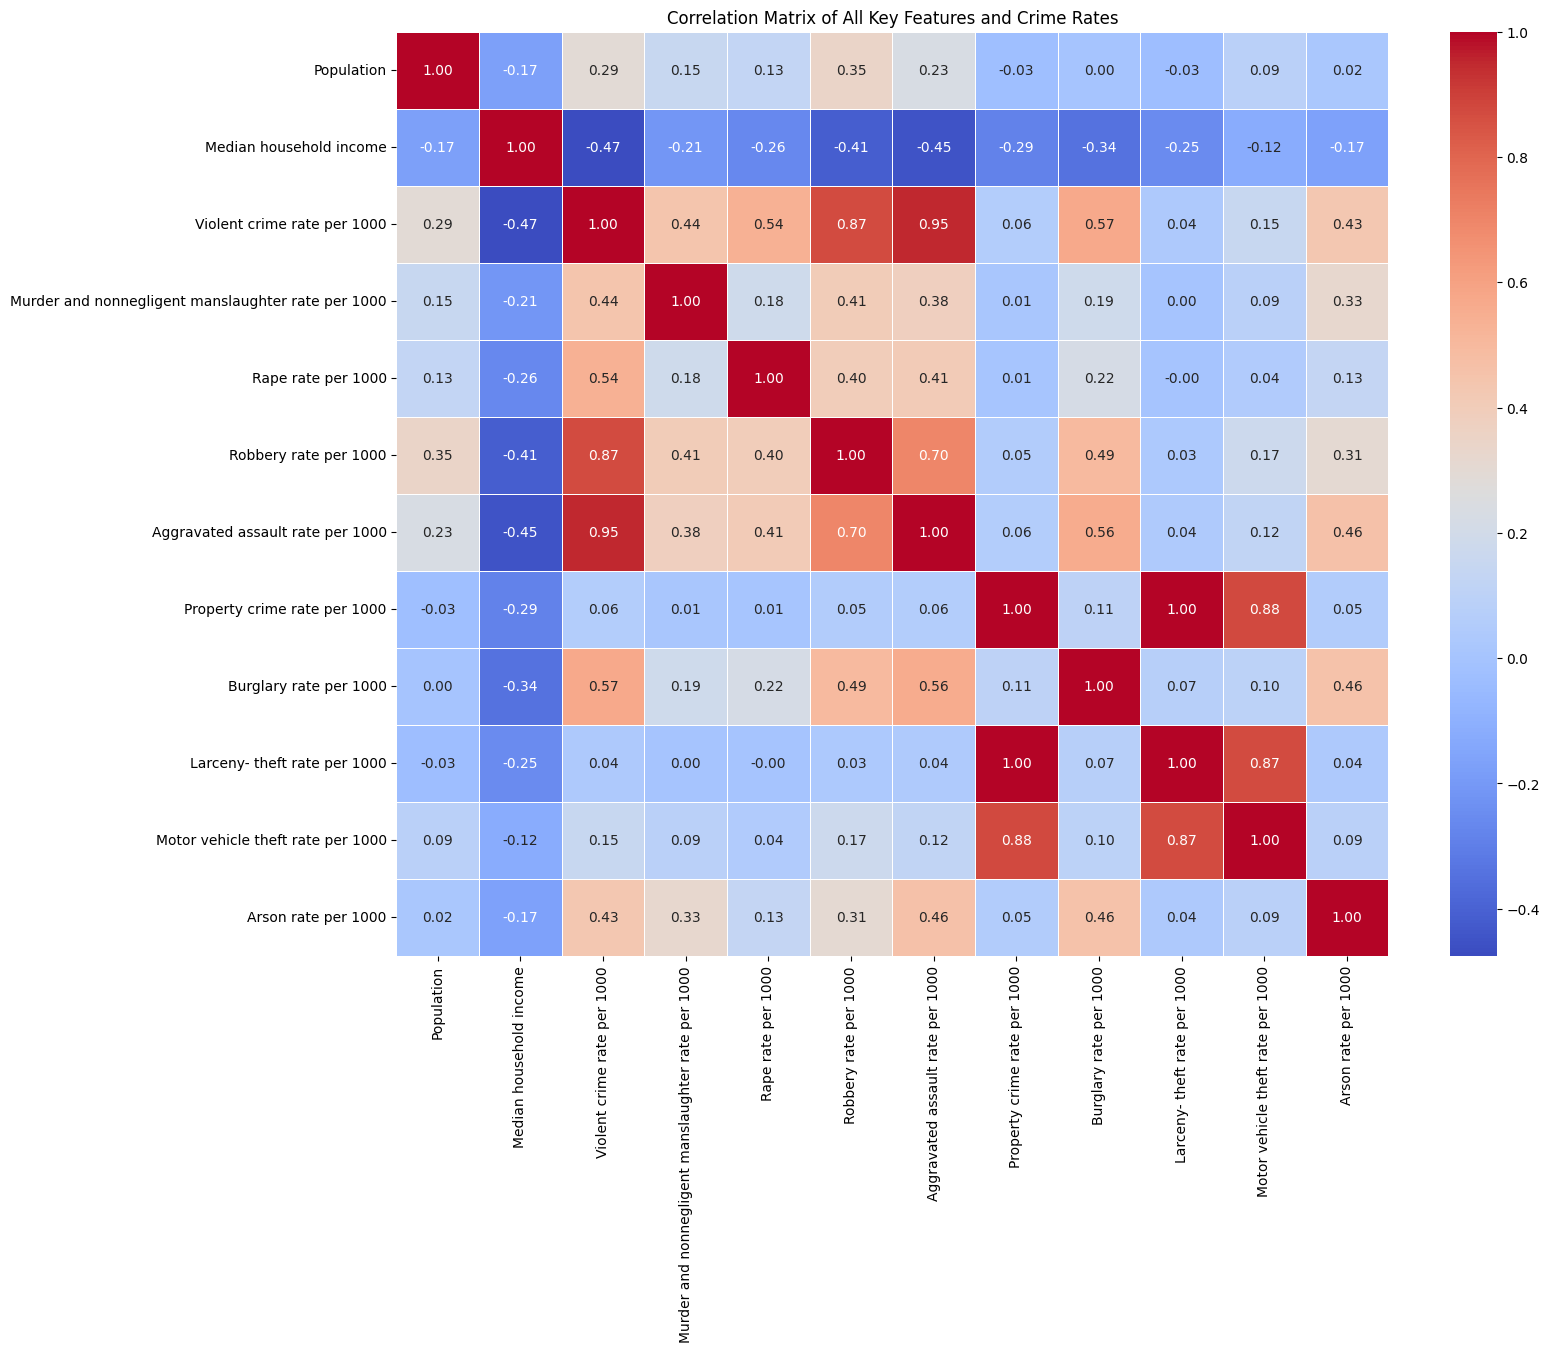

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'data_rates' not in locals() or 'data_rates' not in globals() or not all(f'{col} rate per 1000' in data_rates.columns for col in crime_cols):
    data_rates = data.copy()
    crime_cols = [
        'Violent crime',
        'Murder and nonnegligent manslaughter',
        'Rape',
        'Robbery',
        'Aggravated assault',
        'Property crime',
        'Burglary',
        'Larceny- theft',
        'Motor vehicle theft',
        'Arson'
    ]
    for col in crime_cols:
        data_rates[f'{col} rate per 1000'] = data_rates.apply(lambda row: (row[col] / row['Population']) * 1000 if row['Population'] > 0 else 0, axis=1)

all_cols_for_corr = ['Population', 'Median household income'] + [f'{col} rate per 1000' for col in crime_cols]

correlation_matrix_full = data_rates[all_cols_for_corr].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Key Features and Crime Rates')
plt.show()

# Heatmap Summary
This heatmap is really nice and there are a couple interesting take aways we can instantly tell, just by looking at it.

1. Income vs Crime
    - From what we can see currently, it's possible to already suggest that there is no correlation between crime and income rate.
    - All crime values in the income row are negative, which suggest negative correlation.
    - Although they are all negative, none of them are so negative to suggest that there is definitly no corrleation, but from the heatmap alone, it suggets they may be other outside factors causing the correlation disconnect

2. Strong Crime Clusters
    - There are a lot of strong correlations between certain crimes
      - Motor Vehicle Theif & Property Crime = 0.88
      - Motor Vehicle Theif & Larceny = 0.87
    - This suggest that these crimes often appear together in many towns, which makes sense because they're all different types of theif. This suggests and area of high car theif also has high house theif.

3. Multicollinearity
    - There are a few extreme cases of correlation
      Violent Crime & Aggavated Assault = 0.95
      Property Crime & Larceny Theif = 1.00
    - This suggets that these features are almost entirely redundant, and our model would hypothetically preform the exact same and maybe even better if we were to remove either one of these features.

4. Population vs Crime
    - For the most part there is almost no correlation between population and crime rate
    - This is perfect because this is exactly what we were aiming for by using data_rates to prevent large cities for dominating the data.
    - This is just another justification for nomalizing our crime rates compared to t

# Bivariate Analysis
Now that we understand each features individual distribution, and how each feature correlates to all other features, it's time to focus our sights on our target income.

We can utilize a bivariate analysis which creates scatter plots for each input feature and compares them to the target income. This is important because this allows us to visually test our hypothesis. We're able to provide evidence that could support a hypothesis so instead of just suggesting that a relation is present, we can use the scatterplots to find areas with tight patterns that show strong relationship, as well as identify possible slope predictions for our future linear model.

Below is the creation of our scatterplots, again we are using data_rates to help eliminate the possibility of large cities dominating the data and possibly presenting outliers or shifts that shouldn't occur.

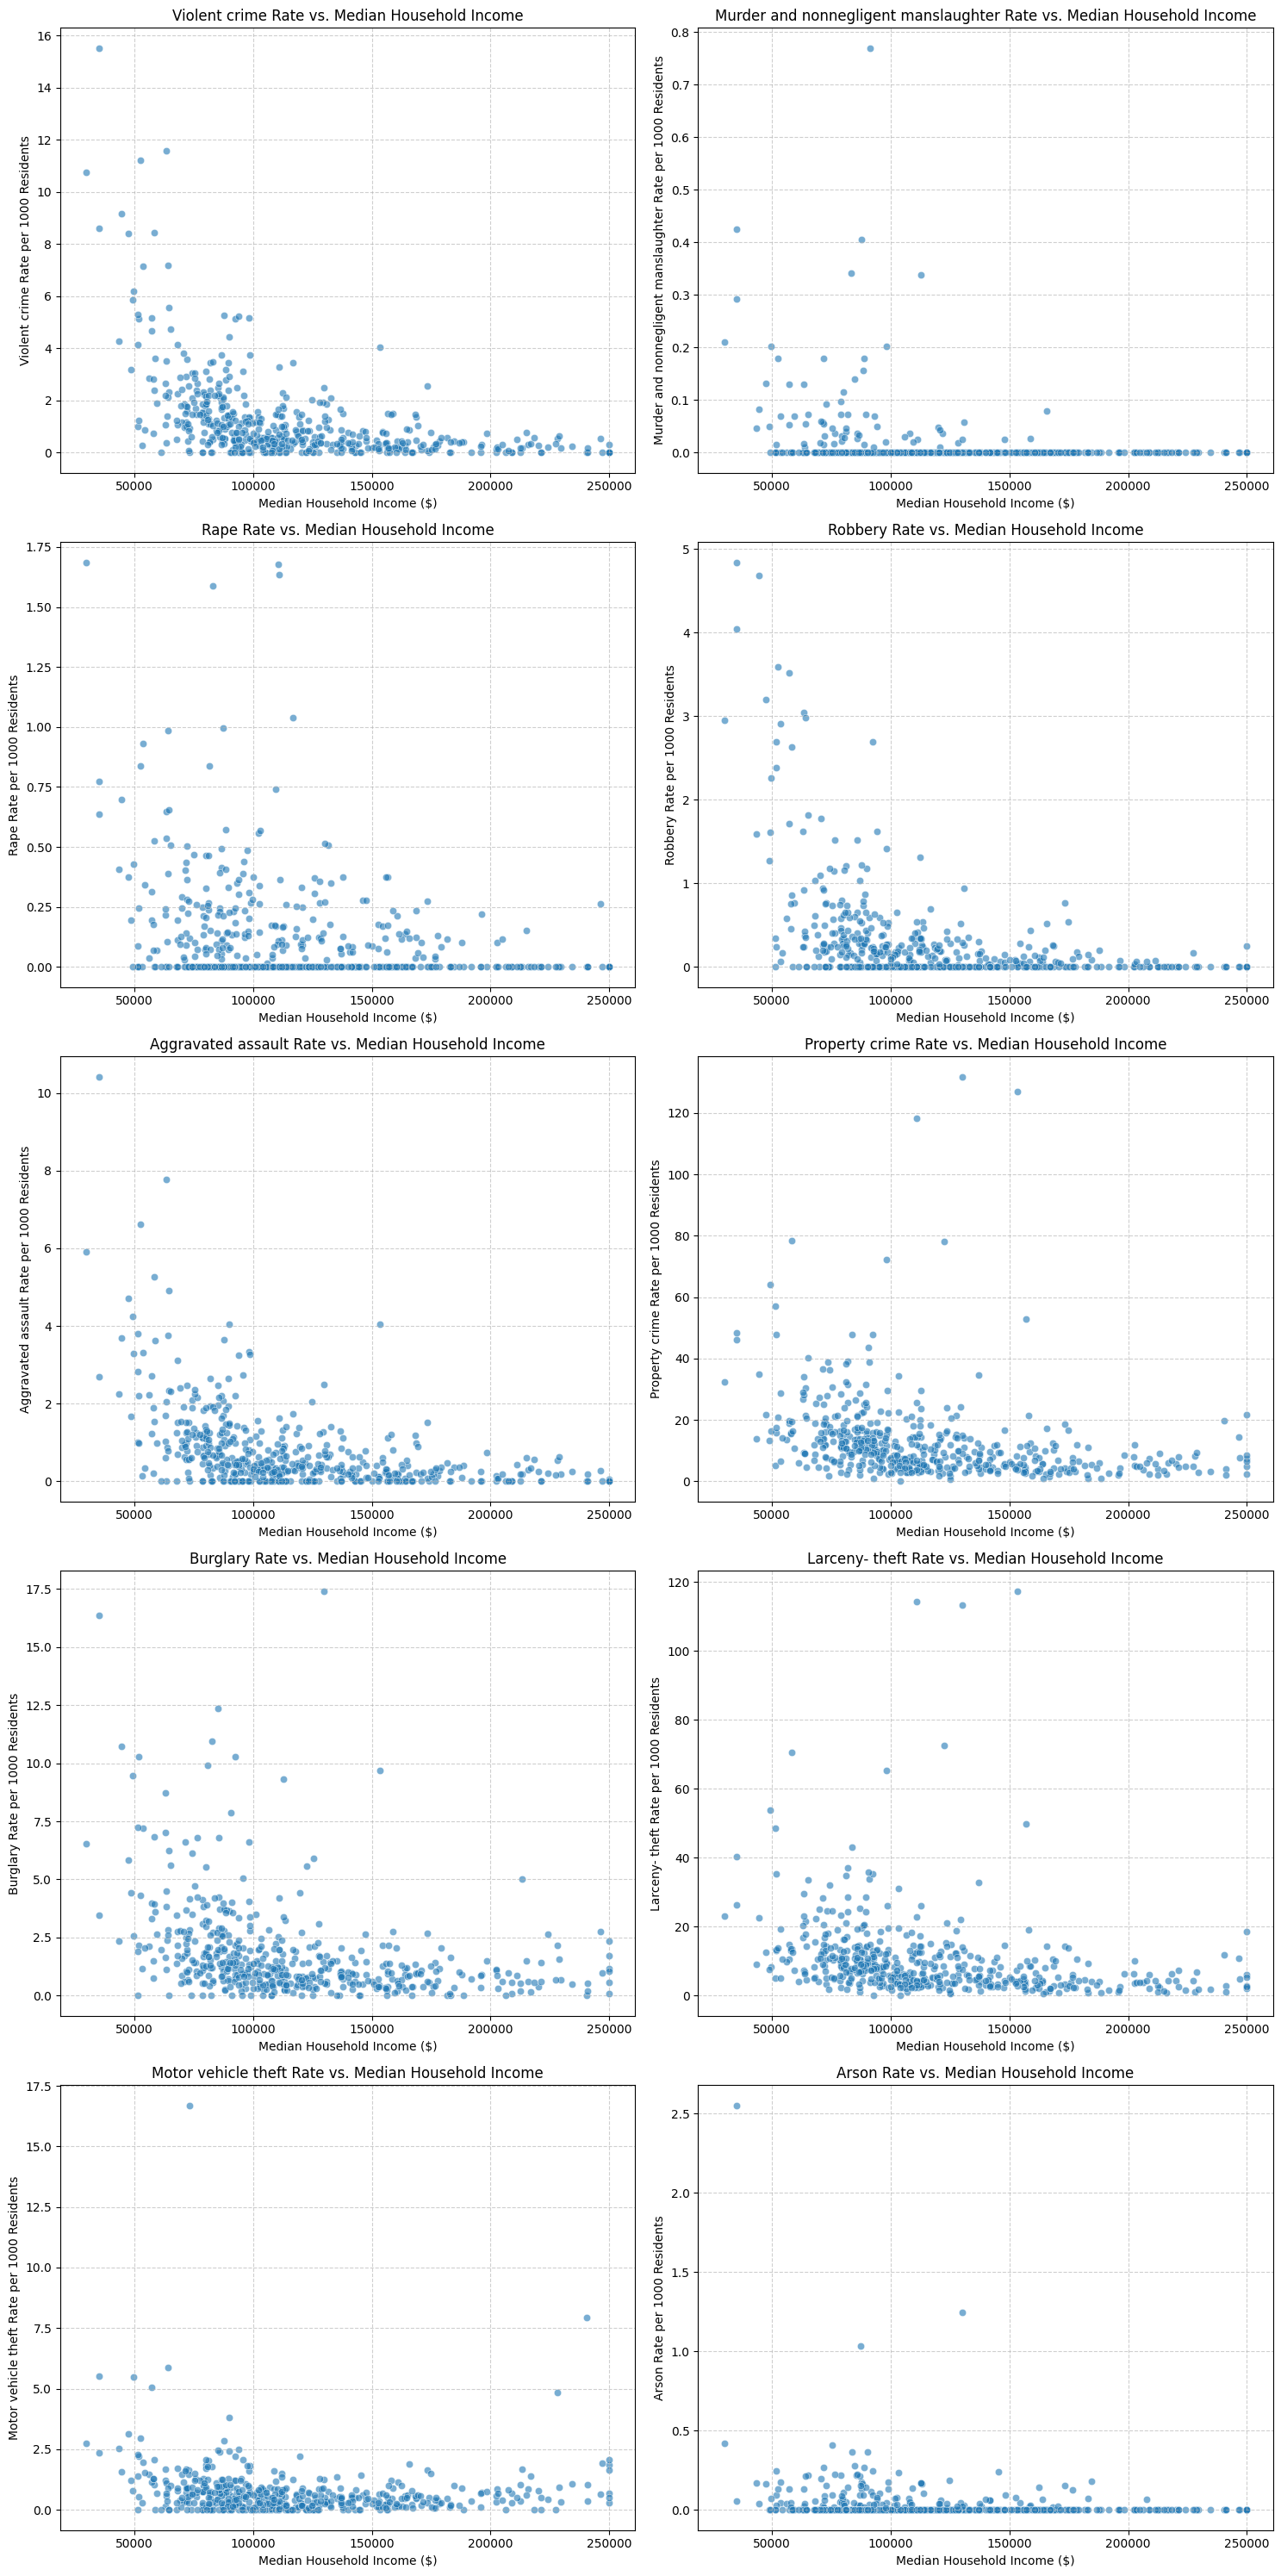

In [ ]:
data_rates = data.copy()
crime_cols = [
    'Violent crime',
    'Murder and nonnegligent manslaughter',
    'Rape',
    'Robbery',
    'Aggravated assault',
    'Property crime',
    'Burglary',
    'Larceny- theft',
    'Motor vehicle theft',
    'Arson'
]

for col in crime_cols:
    data_rates[f'{col} rate per 1000'] = data_rates.apply(lambda row: (row[col] / row['Population']) * 1000 if row['Population'] > 0 else 0, axis=1)

num_crimes = len(crime_cols)
num_cols = 2
num_rows = (num_crimes + num_cols - 1) // num_cols

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 6 * num_rows))
axes = axes.flatten()

for i, col in enumerate(crime_cols):
    rate_col_name = f'{col} rate per 1000'
    sns.scatterplot(
        x='Median household income',
        y=rate_col_name,
        data=data_rates,
        ax=axes[i],
        alpha=0.6
    )
    axes[i].set_title(f'{col} Rate vs. Median Household Income')
    axes[i].set_xlabel('Median Household Income ($)')
    axes[i].set_ylabel(f'{col} Rate per 1000 Residents')
    axes[i].grid(True, linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Bivariate Analysis Summary
The scatterplots are able to provide us with some good evidence as to what our model may prove later. Across all crimes, there is a clear negative relationship between the features, with more crimes seemingly being committed in lower income areas.

Even with that being said, there are a few examples of crimes that seem to show almost no relationship with the income of the area they are committed. Crimes such as arson, rape and murder, while still showing a negative relation, occur at such a small frequency that it's almost impossible to suggest there is any relation between those crimes and the income in the area.

Other crimes such as Larceny and Property, also show negative relations, however the fall off rate is so slow, that you could suggest that even crimes such as those, are almost equally likely across New Jersey, reguardless of average income.


# Hypothesis Testing
Our inital hypothesis was that there was no correlation between crime rate and the average income of an area. In this section we test that hypothesis using a Chi-square test of independence by dividing the average income into 4 groups, and then categorizing crime rates into 3 categories (low, medium and high). By doing this, we expect to have an equal value of all 3 crime levels in each quartile. If this is true, it would support our claim that there is no relationship between crime and income.

violent_crime_category,Low Crime Rate,Medium Crime Rate,High Crime Rate
income_category,,,
Q1 (Lowest Income),9,28,87
Q2,28,50,45
Q3,46,51,26
Q4 (Highest Income),82,34,7



Chi-squared Statistic: 164.90
P-value: 0.000
Degrees of Freedom: 6


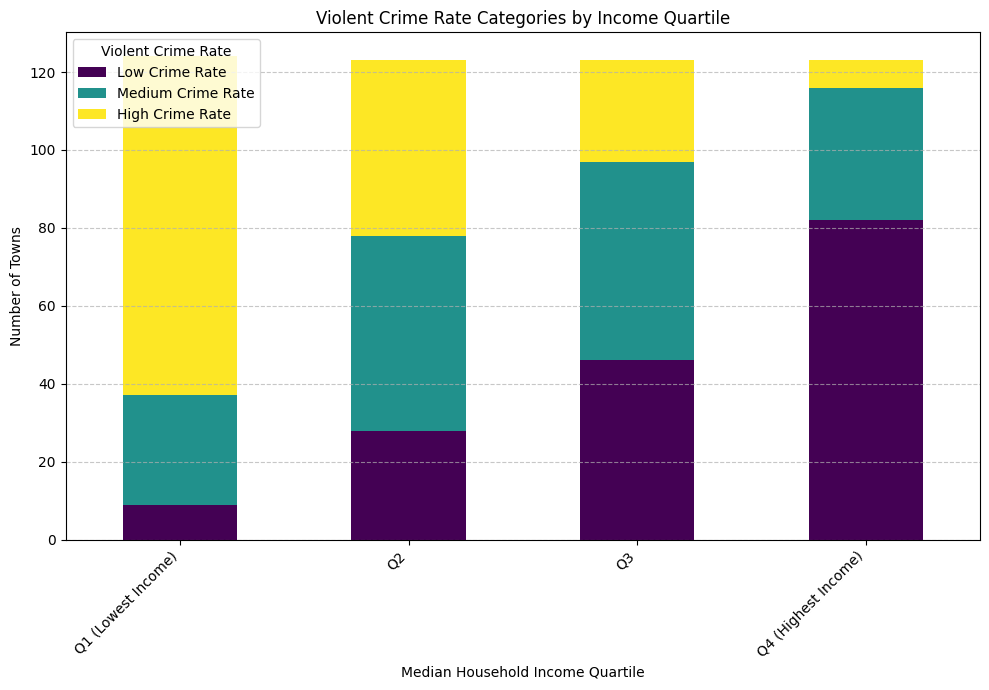

In [ ]:
from scipy.stats import chi2_contingency

# Ensure data_for_anova is available (from previous cell or re-run)
if 'data_for_anova' not in locals() or 'data_for_anova' not in globals() or 'income_category' not in data_for_anova.columns:
    data_rates = data.copy()
    crime_cols = [
        'Violent crime',
        'Murder and nonnegligent manslaughter',
        'Rape',
        'Robbery',
        'Aggravated assault',
        'Property crime',
        'Burglary',
        'Larceny- theft',
        'Motor vehicle theft',
        'Arson'
    ]
    for col in crime_cols:
        data_rates[f'{col} rate per 1000'] = data_rates.apply(lambda row: (row[col] / row['Population']) * 1000 if row['Population'] > 0 else 0, axis=1)
    data_for_anova = data_rates.dropna(subset=['Median household income', 'Violent crime rate per 1000']).copy()
    data_for_anova['income_category'] = pd.qcut(
        data_for_anova['Median household income'],
        q=4,
        labels=['Q1 (Lowest Income)', 'Q2', 'Q3', 'Q4 (Highest Income)']
    )

# Categorize 'Violent crime rate per 1000'
# Using quantiles to create 'Low', 'Medium', 'High' crime rate categories
data_for_anova['violent_crime_category'] = pd.qcut(
    data_for_anova['Violent crime rate per 1000'],
    q=3, # Create 3 categories
    labels=['Low Crime Rate', 'Medium Crime Rate', 'High Crime Rate']
)

# Create a contingency table
contingency_table = pd.crosstab(
    data_for_anova['income_category'],
    data_for_anova['violent_crime_category']
)

display(contingency_table)

# Perform Chi-squared test for independence
chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared Statistic: {chi2:.2f}")
print(f"P-value: {p_chi2:.3f}")
print(f"Degrees of Freedom: {dof}")

# Visualize the relationship with a stacked bar chart
contingency_table.plot(kind='bar', stacked=True, figsize=(10, 7), cmap='viridis')
plt.title('Violent Crime Rate Categories by Income Quartile')
plt.xlabel('Median Household Income Quartile')
plt.ylabel('Number of Towns')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Violent Crime Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Hypothesis Summary
The data here is extreme, and it shocked our group when we first ran the Chi-Square test. We had assumed optimiztically that there would be no correlation, but knew that even if there was some correlation, we would understand that and be able to contribute that to our data.

However, seeing the graph shows the opposite of what we assumed. There is a clear gradient across each quartile, suggesting there is a very strong negative relationship between crime and income.

<br>
<br>

Because of this and since the p-value (0.000) is less than the significance level (0.05), we are forced to reject the Null Hypothesis.

This suggests that Violent crime rate per 1000 are dependent on Median household income.

# Building Machine Learning Models to Test our Hypothesis

After exploring the data and confirming a statistically significant relationship between crime rates and income via Chi-squared testing, we can move on to building predictive models. We decided that the best model to build for our test would be a linear model, however we felt that just providing a single model would be lackluster so we ended up deciding to build 3 model to test different things.


**Model  1 (Individual)**: Our first model will be tested using each crime as it's own feature. This is the type of model we've seen many times in class and other assignments where multiple features, each applied with their own weight, work together to produce an accurate prediction. Although this is technically the first model we're testing, it was the second one we decided to create when it was suggested to split the crimes to try and identify if any one single crime is better at predicting income versus other features.

**Model 2 (Total)**: The sceond model will be using just the Total Crime Rate per 1000. This model is definetly interesting because since it's the total number of crimes, the model would suggets that a town with 20 Larceny crimes, would be considered more dangerous than a town with 19 Arson crimes. I'm interesting to see how the total will affect our models outcome, either helping it be more accurate, or less accurate because it isn't able to distinguish the severity of individual crimes.

**Model 3 (Polynomial Regression)**: This model was last minute planned, I decided to add it after already running both models and being upset with some of the scores we were getting, so I decided to implement a non-linear model to see if I could get any better results that before.

<br>

We predict either one of two things will happen with these two models.
* Model 1 will preform slightly better than Model 2, due to the extra features helping to be slightly more accurate

* Model 2 will preform significantly better.

We think that the extra features will either help a little bit, or cause overfitting and totally ruin the model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Use the subcategory crime rates only
subcategory_crimes = [
    'Murder and nonnegligent manslaughter',
    'Rape',
    'Robbery',
    'Aggravated assault',
    'Burglary',
    'Larceny- theft',
    'Motor vehicle theft',
    'Arson'
]

rate_features = [f'{col} rate per 1000' for col in subcategory_crimes]

# Create total crime rate from subcategories
data_rates['Total crime rate per 1000'] = data_rates[rate_features].sum(axis=1)

# Drop rows with missing income
model_data = data_rates.dropna(subset=['Median household income'] + rate_features).copy()

y = model_data['Median household income']

print(f'Modeling dataset: {model_data.shape[0]} towns')
print(f'Individual features ({len(rate_features)}): {rate_features}')

Modeling dataset: 493 towns
Individual features (8): ['Murder and nonnegligent manslaughter rate per 1000', 'Rape rate per 1000', 'Robbery rate per 1000', 'Aggravated assault rate per 1000', 'Burglary rate per 1000', 'Larceny- theft rate per 1000', 'Motor vehicle theft rate per 1000', 'Arson rate per 1000']


## Model 1: Individual Crime Types

In [ ]:
X_individual = model_data[rate_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_individual, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)

y_pred_train1 = model1.predict(X_train_scaled)
y_pred_test1 = model1.predict(X_test_scaled)

print('Model 1: Individual Crime Types')
print(f'Training R²:  {r2_score(y_train, y_pred_train1):.4f}')
print(f'Testing R²:   {r2_score(y_test, y_pred_test1):.4f}')
print(f'Test RMSE:    ${root_mean_squared_error(y_test, y_pred_test1):,.0f}')
print(f'Test MAE:     ${mean_absolute_error(y_test, y_pred_test1):,.0f}')

# Standardized coefficients — directly show which crimes matter most
coef_df = pd.DataFrame({
    'Crime Type': rate_features,
    'Coefficient': model1.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('\nStandardized Coefficients (ranked by impact):')
for _, row in coef_df.iterrows():
    direction = '↓' if row['Coefficient'] < 0 else '↑'
    print(f'  {direction} {row["Crime Type"]:45s} {row["Coefficient"]:>10,.0f}')


Model 1: Individual Crime Types
Training R²:  0.2404
Testing R²:   0.2552
Test RMSE:    $39,618
Test MAE:     $29,967

Standardized Coefficients (ranked by impact):
  ↓ Aggravated assault rate per 1000                 -11,085
  ↓ Robbery rate per 1000                             -7,982
  ↓ Burglary rate per 1000                            -6,571
  ↑ Arson rate per 1000                                4,729
  ↓ Rape rate per 1000                                -3,530
  ↑ Motor vehicle theft rate per 1000                  3,331
  ↓ Murder and nonnegligent manslaughter rate per 1000     -1,618
  ↓ Larceny- theft rate per 1000                      -1,423


,Murder and nonnegligent manslaughter rate per 1000,Rape rate per 1000,Robbery rate per 1000,Aggravated assault rate per 1000,Burglary rate per 1000,Larceny- theft rate per 1000,Motor vehicle theft rate per 1000,Arson rate per 1000
0,0.0,0.160428,0.267380,0.374332,0.374332,7.754011,0.641711,0.0
1,0.0,0.118540,0.237079,0.592698,2.844950,24.537696,0.592698,0.0
2,0.0,0.000000,0.000000,0.000000,1.177336,3.826343,0.588668,0.0
3,0.0,0.000000,0.000000,0.000000,2.066116,18.595041,2.066116,0.0
4,0.0,0.000000,0.000000,0.000000,1.121076,3.363229,0.000000,0.0


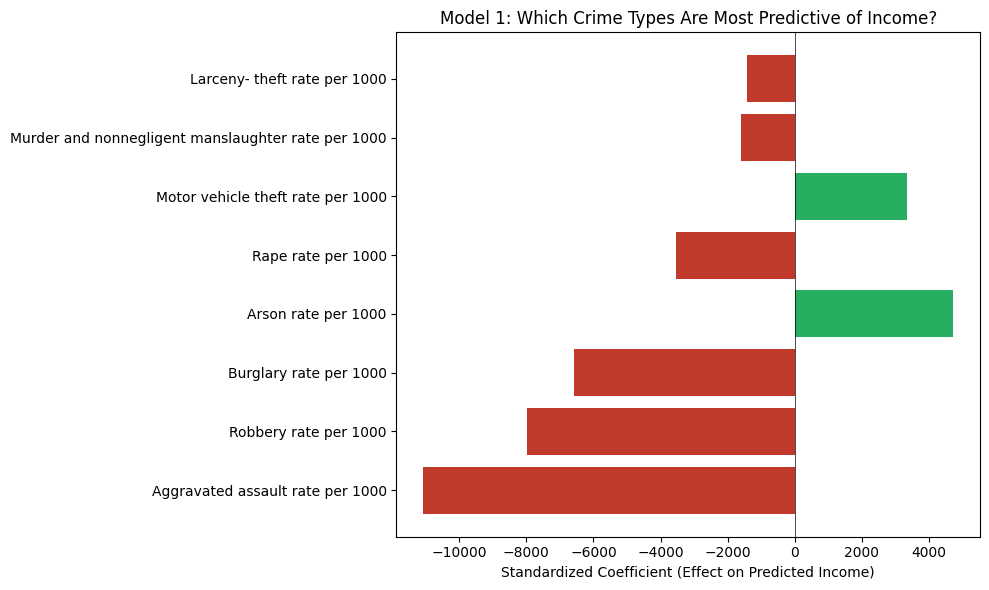

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['#c0392b' if c < 0 else '#27ae60' for c in coef_df['Coefficient']]
plt.barh(coef_df['Crime Type'], coef_df['Coefficient'], color=colors)
plt.xlabel('Standardized Coefficient (Effect on Predicted Income)')
plt.title('Model 1: Which Crime Types Are Most Predictive of Income?')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Model 1 Summary
Our first model preformed under average, only getting an training R² score of 0.2404, and testing R² of 0.2552. This is fairly underwelming and shows that this model has limited predictive power. What's most interesting from this model is how Arson and Motor Vehicle Theif has positive correlation, suggesting that areas with high rates of those crimes, would likely have higher incomes.

Something positive from this test at least, was that we were able to determine which crime has the greatest effect on average income, that being aggavated assaults.

Although this model didn't preform well, we were still able to gather some interesting information, and could use that to build an even better model if we were to continue with this project.

## Model 2: Total Crime Rate

In [ ]:
X_total = model_data[['Total crime rate per 1000']]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_total, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred_train2 = model2.predict(X_train2)
y_pred_test2 = model2.predict(X_test2)

print('Model 2: Total Crime Rate')
print(f'Training R²:  {r2_score(y_train2, y_pred_train2):.4f}')
print(f'Testing R²:   {r2_score(y_test2, y_pred_test2):.4f}')
print(f'Test RMSE:    ${root_mean_squared_error(y_test2, y_pred_test2):,.0f}')
print(f'Test MAE:     ${mean_absolute_error(y_test2, y_pred_test2):,.0f}')
print(f'\nSlope:      {model2.coef_[0]:,.2f}')
print(f'Intercept:  ${model2.intercept_:,.0f}')
print(f'\nFor every additional crime per 1,000 residents, predicted income changes by ${model2.coef_[0]:,.0f}.')

Model 2: Total Crime Rate
Training R²:  0.0903
Testing R²:   0.1532
Test RMSE:    $42,242
Test MAE:     $32,331

Slope:      -877.88
Intercept:  $128,931

For every additional crime per 1,000 residents, predicted income changes by $-878.


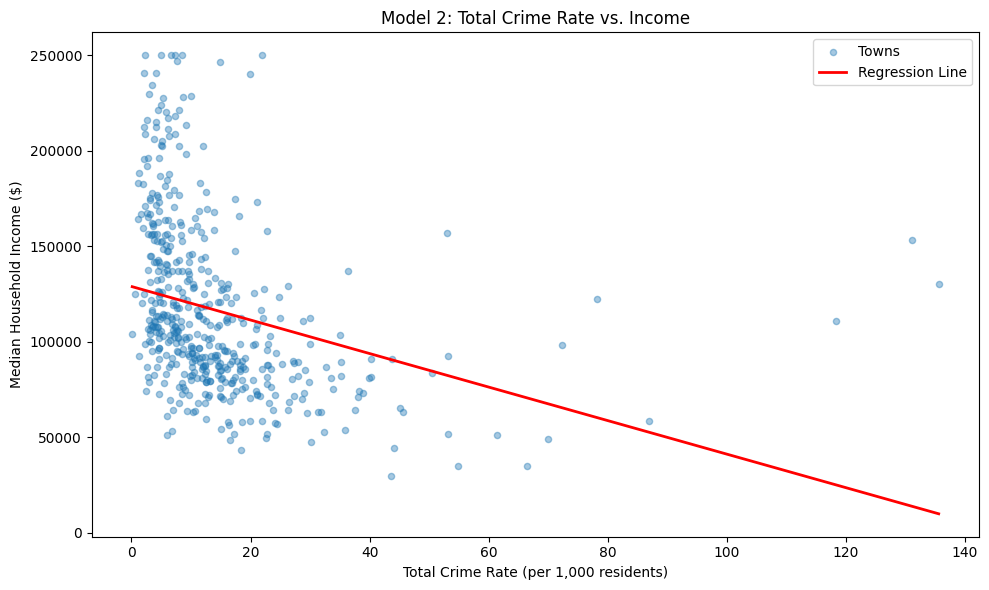

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(model_data['Total crime rate per 1000'], y, alpha=0.4, s=20, label='Towns')

x_line = np.linspace(model_data['Total crime rate per 1000'].min(),
                     model_data['Total crime rate per 1000'].max(), 100)
y_line = model2.intercept_ + model2.coef_[0] * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Total Crime Rate (per 1,000 residents)')
plt.ylabel('Median Household Income ($)')
plt.title('Model 2: Total Crime Rate vs. Income')
plt.legend()
plt.tight_layout()
plt.show()

# Model 2 Summary
This model also preformed poorly, but did even worse than Model 1, getting a training R² of 0.0903, and a testing R² of 0.1532. Essentually this model is only able to explain 9-15% of the variance, and the regression trend line isn't really a trend at all, just a weak suggestion of a trend.

When looking at the plot itself, it easy to see why the model had such a hard time trying to build a linear relationship. Majority of the crime rate distribution is between 0-30, however income is evenly distributed from 50k-250k. This makes it extremely hard to determine when a linear model would run through.

# Model 3 Polynomial

In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

X_individual = model_data[rate_features]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_individual, y, test_size=0.2, random_state=42
)

scaler3 = StandardScaler()

X_train3_scaled = scaler3.fit_transform(X_train3)
X_test3_scaled = scaler3.transform(X_test3)

poly3 = PolynomialFeatures(degree=2, include_bias=False)

X_train3_poly = poly3.fit_transform(X_train3_scaled)
X_test3_poly = poly3.transform(X_test3_scaled)

model3 = Ridge(alpha=30.0)
model3.fit(X_train3_poly, y_train3)

y_pred_train3 = model3.predict(X_train3_poly)
y_pred_test3 = model3.predict(X_test3_poly)

print('Model 3: Ridge Polynomial Regression (Individual Crime Types)')
print(f'Training R²:  {r2_score(y_train3, y_pred_train3):.4f}')
print(f'Testing R²:   {r2_score(y_test3, y_pred_test3):.4f}')
print(f'Test RMSE:    ${root_mean_squared_error(y_test3, y_pred_test3):,.0f}')
print(f'Test MAE:     ${mean_absolute_error(y_test3, y_pred_test3):,.0f}')


Model 3: Ridge Polynomial Regression (Individual Crime Types)
Training R²:  0.4046
Testing R²:   0.3377
Test RMSE:    $37,357
Test MAE:     $28,788


# Model 3 Summary
As far as R² and RMSE scores go, this is our best model by far. Able to get a training R² of 0.4046 and testing R² of 0.3377. This is our best model we were able to make and currently is able to accuratley predict around 1/3 of the variance in our data.

Despite it being the best model we were able to build it's still not perfect, which suggests there are other factors that could be utilized to create better predictions.

## Model Comparison and Hypothesis Conclusion

In [ ]:
from scipy import stats

comparison = pd.DataFrame({
    'Metric': ['Training R²', 'Testing R²', 'Test RMSE ($)', 'Test MAE ($)'],
    'Model 1 (Individual Crimes)': [
        f'{r2_score(y_train, y_pred_train1):.4f}',
        f'{r2_score(y_test, y_pred_test1):.4f}',
        f'{root_mean_squared_error(y_test, y_pred_test1):,.0f}',
        f'{mean_absolute_error(y_test, y_pred_test1):,.0f}'
    ],
    'Model 2 (Total Crime)': [
        f'{r2_score(y_train2, y_pred_train2):.4f}',
        f'{r2_score(y_test2, y_pred_test2):.4f}',
        f'{root_mean_squared_error(y_test2, y_pred_test2):,.0f}',
        f'{mean_absolute_error(y_test2, y_pred_test2):,.0f}'
    ],
    'Model 3: Ridge Polynomial Regression':[
        f'{r2_score(y_train3, y_pred_train3):.4f}',
        f'{r2_score(y_test3, y_pred_test3):.4f}',
        f'{root_mean_squared_error(y_test3, y_pred_test3):,.0f}',
        f'{mean_absolute_error(y_test3, y_pred_test3):,.0f}'
    ]
})

print('Model Comparison')
display(comparison)

# Pearson correlation test for hypothesis conclusion
r, p_value = stats.pearsonr(model_data['Total crime rate per 1000'], y)

print(f'\nPearson Correlation Test')
print(f'H₀: No linear correlation between crime rate and income (ρ = 0)')
print(f'H₁: A linear correlation exists (ρ ≠ 0)')
print(f'Pearson r = {r:.4f}, p = {p_value:.2e}')
print(f'\nAt α = 0.05: {"Reject" if p_value < 0.05 else "Fail to reject"} the null hypothesis.')

Model Comparison


,Metric,Model 1 (Individual Crimes),Model 2 (Total Crime),Model 3: Ridge Polynomial Regression
0,Training R²,0.2404,0.0903,0.4046
1,Testing R²,0.2552,0.1532,0.3377
2,Test RMSE ($),"39,618","42,242","37,357"
3,Test MAE ($),"29,967","32,331","28,788"



Pearson Correlation Test
H₀: No linear correlation between crime rate and income (ρ = 0)
H₁: A linear correlation exists (ρ ≠ 0)
Pearson r = -0.3263, p = 1.08e-13

At α = 0.05: Reject the null hypothesis.
There is a statistically significant negative linear relationship between crime rates and income.


# Conclusion
Across all three of our models we were able to get various results of success, but all of our models showed evidence of a moderate relationship between crime rate and average income. Pearson's correlation of r = -0.3263 and p < 0.001 both confirm a negative relationship, proving that higher crime rates are associated with lower incomes.

Despite this finding however, our models showed that crime is a relative signal for income prediction, but additional social features such as education, employment or housing data would need to be accessable to build a more accurate prediction.

<br>

I'm very happy with how we handled this assignment as a group and I think that while our original hypothesis of 0 correlation has been proven wrong, I found it very rewarding that we were able to show that income is not the only prediction for crime rate, and that there are other issues